# Lab 3 — Supervised Machine Learning Models

**Datasets:** California Housing (Regression) & PIMA Indians Diabetes (Classification)

**Goals:** Train and compare multiple supervised models including Linear Regression, Decision Trees, SVM, Random Forest, Naive Bayes, and Neural Networks using TensorFlow/Keras.

This notebook is ready-to-run in Jupyter or Google Colab. Some cells may take time depending on your environment.

## 1. Setup & Imports

Install required packages if not already available (uncomment the pip lines in Colab).

In [1]:
# Uncomment if running in a fresh Colab environment
# !pip install --quiet scikit-learn pandas numpy matplotlib seaborn tensorflow

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.svm import SVR, SVC
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

#Neural Network Related Packages
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('Libraries imported. TensorFlow version:', tf.__version__)

Libraries imported. TensorFlow version: 2.19.0


## 2. Load Datasets

In [2]:
# California Housing (Regression)
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
df_h = housing.frame.copy()
df_h.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [3]:
# PIMA Indians Diabetes (Classification)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"]
df_p = pd.read_csv(url, names=cols)
df_p.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. Preprocessing

- Basic cleaning, handling zero-as-missing in PIMA, scaling, and train-test split.

In [4]:
# --- California Housing preprocessing ---
X_h = df_h.drop(columns=['MedHouseVal'])
y_h = df_h['MedHouseVal']

# Train-test split
Xh_train, Xh_test, yh_train, yh_test = train_test_split(X_h, y_h, test_size=0.2, random_state=42) #20% data for testing

# Scale features
scaler_h = StandardScaler()
Xh_train_scaled = scaler_h.fit_transform(Xh_train)
Xh_test_scaled = scaler_h.transform(Xh_test)

print('California: train shape', Xh_train.shape, 'test shape', Xh_test.shape)

California: train shape (16512, 8) test shape (4128, 8)


In [5]:
# --- PIMA preprocessing ---
df_p_clean = df_p.copy()

# In PIMA, zeros in certain columns indicate missing values
cols_missing = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df_p_clean[cols_missing] = df_p_clean[cols_missing].replace(0, pd.NA)

# Impute with median
for c in cols_missing:
    df_p_clean[c] = df_p_clean[c].fillna(df_p_clean[c].median())

X_p = df_p_clean.drop(columns=['Outcome'])
y_p = df_p_clean['Outcome']

Xp_train, Xp_test, yp_train, yp_test = train_test_split(X_p, y_p, test_size=0.2, random_state=42, stratify=y_p)

# Scale features
scaler_p = StandardScaler()
Xp_train_scaled = scaler_p.fit_transform(Xp_train)
Xp_test_scaled = scaler_p.transform(Xp_test)

print('PIMA: train shape', Xp_train.shape, 'test shape', Xp_test.shape)
print('Class distribution (train):\n', yp_train.value_counts(normalize=True))

PIMA: train shape (614, 8) test shape (154, 8)
Class distribution (train):
 Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64


## 4. Regression Models (California Housing)
Models: Linear Regression, Decision Tree, Random Forest, SVR, Keras Neural Network

Evaluation: RMSE, MAE, R²

In [6]:
def regression_metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

results_reg = {}

In [7]:
# 4.1 Linear Regression
lr = LinearRegression()
lr.fit(Xh_train_scaled, yh_train)
y_lr = lr.predict(Xh_test_scaled)
results_reg['LinearRegression'] = regression_metrics(yh_test, y_lr)
results_reg['LinearRegression']

{'RMSE': 0.5558915986952442,
 'MAE': 0.5332001304956565,
 'R2': 0.575787706032451}

In [8]:
# 4.2 Decision Tree Regressor
dtr = DecisionTreeRegressor(max_depth=6, random_state=42)
dtr.fit(Xh_train_scaled, yh_train)
y_dtr = dtr.predict(Xh_test_scaled)
results_reg['DecisionTreeRegressor'] = regression_metrics(yh_test, y_dtr)
results_reg['DecisionTreeRegressor']

{'RMSE': 0.4972838079675652,
 'MAE': 0.5008044131156354,
 'R2': 0.6205125146233951}

In [9]:
# 4.3 Random Forest Regressor
rfr = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rfr.fit(Xh_train_scaled, yh_train)
y_rfr = rfr.predict(Xh_test_scaled)
results_reg['RandomForestRegressor'] = regression_metrics(yh_test, y_rfr)
results_reg['RandomForestRegressor']

{'RMSE': 0.29629821968969944,
 'MAE': 0.36628865979805514,
 'R2': 0.7738887441938533}

In [10]:
# 4.4 Support Vector Regressor (SVR)
# Note: SVR can be slow on large datasets; we demonstrate on a subset for speed.
svr = SVR(C=1.0, kernel='rbf')
svr.fit(Xh_train_scaled[:2000], yh_train[:2000])
y_svr = svr.predict(Xh_test_scaled)
results_reg['SVR_subset_fit'] = regression_metrics(yh_test, y_svr)
results_reg['SVR_subset_fit']

{'RMSE': 0.4108115870179367,
 'MAE': 0.43409372083776865,
 'R2': 0.686501242101216}

In [11]:
# 4.5 Neural Network (Keras) for Regression
tf.random.set_seed(42)
model_reg = keras.Sequential([
    layers.Input(shape=(Xh_train_scaled.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])
model_reg.compile(optimizer='adam', loss='mse', metrics=['mae'])
es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_reg.fit(Xh_train_scaled, yh_train, validation_split=0.15, epochs=100, batch_size=32, callbacks=[es], verbose=0)
y_keras = model_reg.predict(Xh_test_scaled).ravel()
results_reg['Keras_DNN'] = regression_metrics(yh_test, y_keras)
results_reg['Keras_DNN']

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


{'RMSE': 0.26140097156879594,
 'MAE': 0.34427168527899094,
 'R2': 0.8005195508354177}

In [12]:
# Show regression results
pd.DataFrame(results_reg).T

,RMSE,MAE,R2
LinearRegression,0.555892,0.533200,0.575788
DecisionTreeRegressor,0.497284,0.500804,0.620513
RandomForestRegressor,0.296298,0.366289,0.773889
SVR_subset_fit,0.410812,0.434094,0.686501
Keras_DNN,0.261401,0.344272,0.800520


### Regression: Predicted Values (Random Forest & DTR)

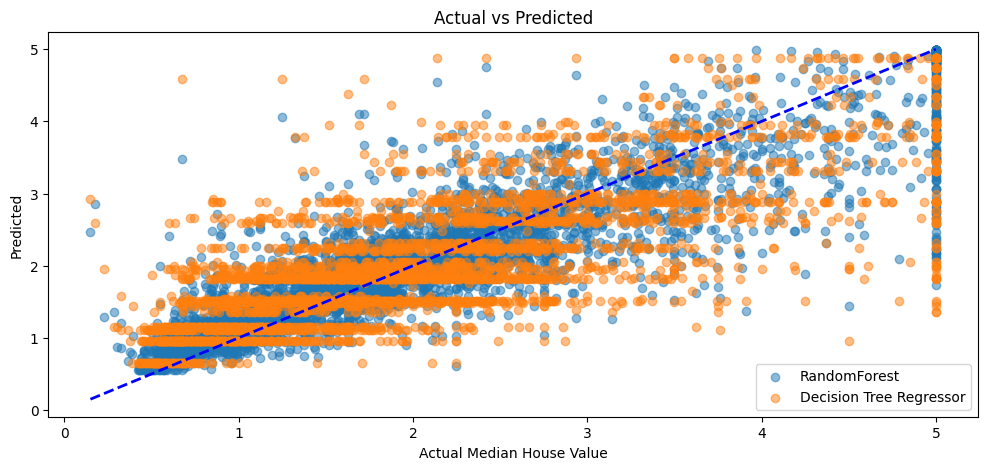

In [13]:
plt.figure(figsize=(12,5))
plt.scatter(yh_test, y_rfr, alpha=0.5, label='RandomForest')
plt.scatter(yh_test, y_dtr, alpha=0.5, label='Decision Tree Regressor')
plt.plot([yh_test.min(), yh_test.max()], [yh_test.min(), yh_test.max()], 'b--', lw=2)
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted')
plt.legend()
plt.title('Actual vs Predicted')
plt.show()

## 5. Classification Models (PIMA Indians Diabetes)
Models: Logistic Regression, Decision Tree, Random Forest, SVM, Naive Bayes, Keras Neural Network

Evaluation: Accuracy, Precision, Recall, F1, ROC-AUC

In [14]:
results_clf = {}

In [15]:
# 5.1 Logistic Regression
logr = LogisticRegression(max_iter=1000)
logr.fit(Xp_train_scaled, yp_train)
yp_lr = logr.predict(Xp_test_scaled)
results_clf['LogisticRegression'] = {
    'accuracy': accuracy_score(yp_test, yp_lr),
    'roc_auc': roc_auc_score(yp_test, logr.predict_proba(Xp_test_scaled)[:,1])
}
results_clf['LogisticRegression']

{'accuracy': 0.7077922077922078, 'roc_auc': np.float64(0.812962962962963)}

In [16]:
# 5.2 Decision Tree Classifier
dtc = DecisionTreeClassifier(max_depth=6, random_state=42)
dtc.fit(Xp_train_scaled, yp_train)
yp_dtc = dtc.predict(Xp_test_scaled)
results_clf['DecisionTree'] = {
    'accuracy': accuracy_score(yp_test, yp_dtc),
    'roc_auc': roc_auc_score(yp_test, dtc.predict_proba(Xp_test_scaled)[:,1])
}
results_clf['DecisionTree']

{'accuracy': 0.7467532467532467, 'roc_auc': np.float64(0.7904629629629629)}

In [17]:
# 5.3 Random Forest Classifier
rfc = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rfc.fit(Xp_train_scaled, yp_train)
yp_rfc = rfc.predict(Xp_test_scaled)
results_clf['RandomForest'] = {
    'accuracy': accuracy_score(yp_test, yp_rfc),
    'roc_auc': roc_auc_score(yp_test, rfc.predict_proba(Xp_test_scaled)[:,1])
}
results_clf['RandomForest']

{'accuracy': 0.7467532467532467, 'roc_auc': np.float64(0.8122222222222222)}

In [18]:
# 5.4 SVM (with probability for ROC)
svc = SVC(kernel='rbf', probability=True)
svc.fit(Xp_train_scaled, yp_train)
yp_svc = svc.predict(Xp_test_scaled)
results_clf['SVM'] = {
    'accuracy': accuracy_score(yp_test, yp_svc),
    'roc_auc': roc_auc_score(yp_test, svc.predict_proba(Xp_test_scaled)[:,1])
}
results_clf['SVM']

{'accuracy': 0.7402597402597403, 'roc_auc': np.float64(0.7963888888888889)}

In [19]:
# 5.5 Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(Xp_train_scaled, yp_train)
yp_gnb = gnb.predict(Xp_test_scaled)
results_clf['GaussianNB'] = {
    'accuracy': accuracy_score(yp_test, yp_gnb),
    'roc_auc': roc_auc_score(yp_test, gnb.predict_proba(Xp_test_scaled)[:,1])
}
results_clf['GaussianNB']

{'accuracy': 0.7012987012987013, 'roc_auc': np.float64(0.7646296296296297)}

In [20]:
# 5.6 Keras Neural Network for Classification
tf.random.set_seed(42)
model_clf = keras.Sequential([
    layers.Input(shape=(Xp_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
model_clf.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
es2 = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_clf = model_clf.fit(Xp_train_scaled, yp_train, validation_split=0.15, epochs=100, batch_size=32, callbacks=[es2], verbose=0)
yp_keras_prob = model_clf.predict(Xp_test_scaled).ravel()
yp_keras = (yp_keras_prob > 0.5).astype(int)

results_clf['Keras_DNN'] = {
    'accuracy': accuracy_score(yp_test, yp_keras),
    'roc_auc': roc_auc_score(yp_test, yp_keras_prob)
}
results_clf['Keras_DNN']

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


{'accuracy': 0.7272727272727273, 'roc_auc': np.float64(0.8205555555555556)}

In [21]:
# Show classification results
pd.DataFrame(results_clf).T

,accuracy,roc_auc
LogisticRegression,0.707792,0.812963
DecisionTree,0.746753,0.790463
RandomForest,0.746753,0.812222
SVM,0.740260,0.796389
GaussianNB,0.701299,0.764630
Keras_DNN,0.727273,0.820556


### ROC Curves

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


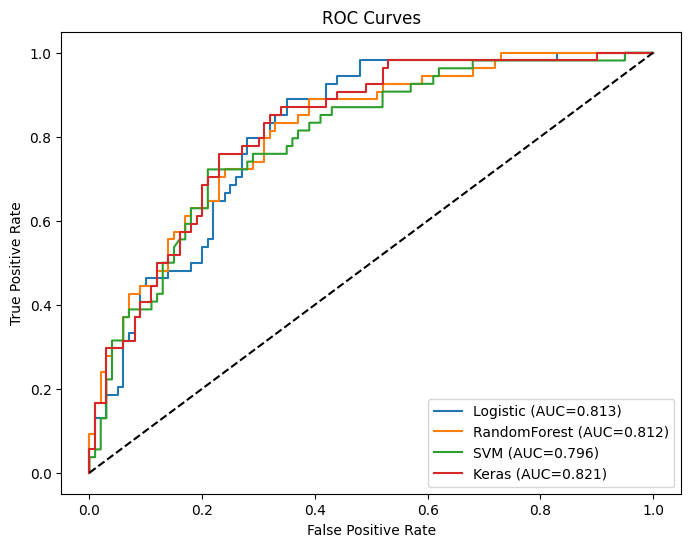

In [22]:
plt.figure(figsize=(8,6))
models_for_roc = {
    'Logistic': (logr, Xp_test_scaled),
    'RandomForest': (rfc, Xp_test_scaled),
    'SVM': (svc, Xp_test_scaled),
    'Keras': (model_clf, Xp_test_scaled)
}

for name, (m, Xtest) in models_for_roc.items():
    if name == 'Keras':
        probs = model_clf.predict(Xtest).ravel()
    else:
        probs = m.predict_proba(Xtest)[:,1]
    fpr, tpr, _ = roc_curve(yp_test, probs)
    auc = roc_auc_score(yp_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

## 6. Model Comparison & Reflection

Compare the tables above. Discuss bias-variance, model strengths, and next steps (hyperparameter tuning, cross-validation, ensembling).

## 7. Exercises for Students

1. Use GridSearchCV to tune RandomForest hyperparameters for PIMA dataset and report best params.

2. For California Housing, try ElasticNet regression and compare RMSE with Linear Regression.

3. Modify the Keras classification network (add/remove layers, change activation) and comment on performance.

4. Plot feature importances for the Random Forest regression model and report top 5 features.

## 8. Solutions


In [23]:
# 8.1 PIMA: RandomForestClassifier hyperparameter tuning with GridSearchCV
from sklearn.model_selection import StratifiedKFold

param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth': [None, 6, 10, 14],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_clf = RandomForestClassifier(random_state=42)

gs_rfc = GridSearchCV(
    estimator=rf_clf,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

gs_rfc.fit(Xp_train_scaled, yp_train)
print('Best Params (PIMA RF):', gs_rfc.best_params_)
print('Best CV ROC-AUC:', gs_rfc.best_score_)

# Evaluate on test set
best_rfc = gs_rfc.best_estimator_
yp_best_prob = best_rfc.predict_proba(Xp_test_scaled)[:,1]
yp_best = (yp_best_prob > 0.5).astype(int)
print('Test Accuracy:', accuracy_score(yp_test, yp_best))
print('Test ROC-AUC:', roc_auc_score(yp_test, yp_best_prob))


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Params (PIMA RF): {'max_depth': 6, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best CV ROC-AUC: 0.8398311184939091
Test Accuracy: 0.7532467532467533
Test ROC-AUC: 0.812962962962963


In [24]:
# 8.2 California Housing: ElasticNet vs Linear Regression (RMSE)
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import KFold

# Linear Regression RMSE (already computed in results_reg); recompute here for clarity
lr2 = LinearRegression()
lr2.fit(Xh_train_scaled, yh_train)
y_lr2 = lr2.predict(Xh_test_scaled)
rmse_lr = mean_squared_error(yh_test, y_lr2)

# ElasticNet with simple CV for alpha and l1_ratio
param_grid_en = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

en = ElasticNet(max_iter=20000, random_state=42)
gs_en = GridSearchCV(en, param_grid_en, scoring='neg_mean_squared_error', cv=5, n_jobs=-1, verbose=0)
gs_en.fit(Xh_train_scaled, yh_train)

best_en = gs_en.best_estimator_
y_en = best_en.predict(Xh_test_scaled)
rmse_en = mean_squared_error(yh_test, y_en)

print('ElasticNet best params:', gs_en.best_params_)
print('RMSE - Linear Regression:', rmse_lr)
print('RMSE - ElasticNet:', rmse_en)


ElasticNet best params: {'alpha': 0.001, 'l1_ratio': 0.9}
RMSE - Linear Regression: 0.5558915986952442
RMSE - ElasticNet: 0.5545735169489012


In [25]:
# 8.3 Modified Keras classification network (PIMA) and performance comparison

tf.random.set_seed(123)
model_clf_mod = keras.Sequential([
    layers.Input(shape=(Xp_train_scaled.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])
model_clf_mod.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

es3 = keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

hist_mod = model_clf_mod.fit(Xp_train_scaled, yp_train, validation_split=0.15, epochs=120, batch_size=32, callbacks=[es3], verbose=0)

yp_mod_prob = model_clf_mod.predict(Xp_test_scaled).ravel()
yp_mod = (yp_mod_prob > 0.5).astype(int)

acc_base = results_clf.get('Keras_DNN', {}).get('accuracy', None)
auc_base = results_clf.get('Keras_DNN', {}).get('roc_auc', None)

acc_mod = accuracy_score(yp_test, yp_mod)
auc_mod = roc_auc_score(yp_test, yp_mod_prob)

print('Base Keras - Accuracy:', acc_base, 'ROC-AUC:', auc_base)
print('Modified Keras - Accuracy:', acc_mod, 'ROC-AUC:', auc_mod)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Base Keras - Accuracy: 0.7272727272727273 ROC-AUC: 0.8205555555555556
Modified Keras - Accuracy: 0.7402597402597403 ROC-AUC: 0.8242592592592592


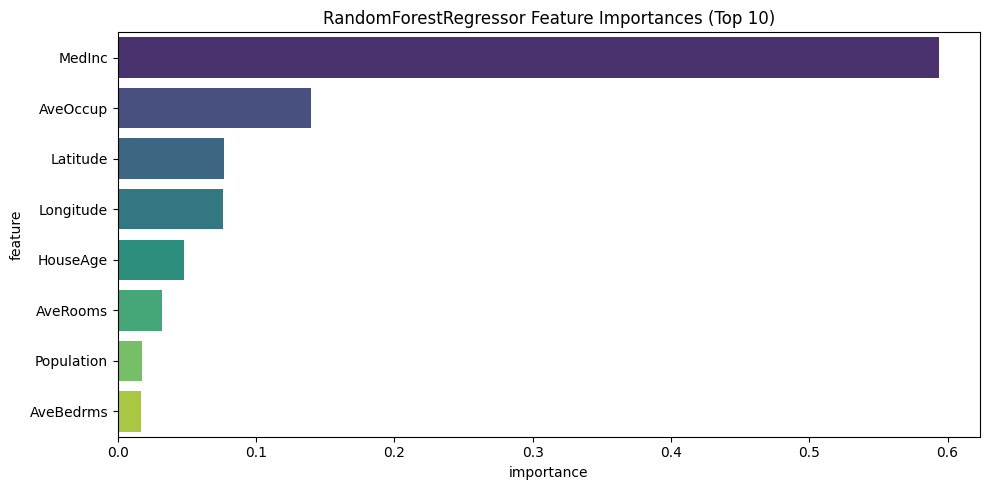

Top 5 features:
     feature  importance
0     MedInc    0.593805
5   AveOccup    0.139759
6   Latitude    0.076593
7  Longitude    0.076106
1   HouseAge    0.047921


In [26]:
# 8.4 Feature importance for RandomForest Regressor (California)

# Ensure rfr exists (from section 4.3). If not, fit a default one.
try:
    _ = rfr.feature_importances_
except NameError:
    rfr = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
    rfr.fit(Xh_train_scaled, yh_train)

importances = rfr.feature_importances_
feature_names = X_h.columns

fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='importance', y='feature', data=fi_df.head(10), palette='viridis')
plt.title('RandomForestRegressor Feature Importances (Top 10)')
plt.tight_layout()
plt.show()

print('Top 5 features:')
print(fi_df.head(5))
